In [72]:
import cv2
import matplotlib.pyplot as plt
from IPython import display
import time
import numpy as np
import scipy.ndimage as ndi

In [143]:
path = "../videos/100ml/trial1/5mm.mp4v"
cap = cv2.VideoCapture(path)

### data from video

1. store the recorded video as a list of images (2D arrays)
2. find the position of the markers 

note: the ball is not visible while its passing the marker, but the 100ml is measured between the tops of the two markers; most convenient solution is to calculate based on the image the length between the bottom of the top marker and the top of the bottom one 

3. crop the video to only include the ball
4. select only the frames where the ball is between the markers

their number will be the travel time (after accounting for fps)

In [137]:
# convert a video into a list of frames
frames = []
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break  # End of video reached
    frames.append(frame)
    frame_count += 1

In [138]:
# transform frames to grayscale and filter for dark objects
new_frames = [np.dot(frame[..., :3], [0.114, 0.587, 0.299]) for frame in frames]
new_frames = [frame < 30 for frame in new_frames]

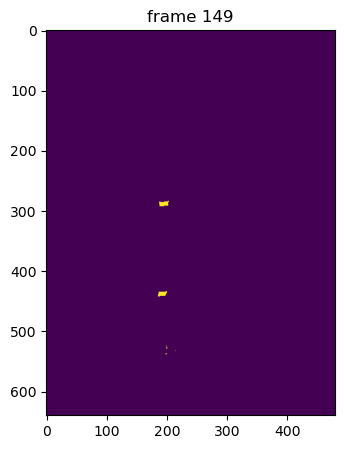

In [140]:
# display the frames from list

# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))

im = ax.imshow(new_frames[0])

for i in range(10, frame_count):
    im.set_data(new_frames[i])
    ax.set_title(f"frame {i}")
    # rerender
    display.display(plt.gcf())
    display.clear_output(wait=True)
    #time.sleep(0.2)

In [141]:
clusters, num_features = ndi.label(new_frames[-1]) # the markers will always be the two largest clusters
print(num_features)

counts = np.bincount(clusters.ravel())
counts[0] = 0 # disregard the background
label1, label2 = np.argsort(counts)[-2:][::-1]

marker1 = clusters==label1
marker2 = clusters==label2

y_coords1 = np.unique(np.argwhere(marker1)[:, 0]) # col0 ycoord; col1 x coord
y_coords2 = np.unique(np.argwhere(marker2)[:, 0])

# choose the two middle values from a list of marker edges
new_range = sorted([min(y_coords1), min(y_coords2), max(y_coords1), max(y_coords2)])[1:3]

6


In [133]:
# UNUSABLE

cropped_frames = [frame[new_range[0]+1:new_range[1]-1, 160:240] for frame in new_frames]
less_frames = []
last = None # will be used to keep track of the index of the last frame
for i in range(frame_count):
    frame=cropped_frames[i]
    if frame.sum() > 0: 
        less_frames.append(frame)
        last = i
less_frames.append(cropped_frames[last+1])
new_count = len(less_frames)

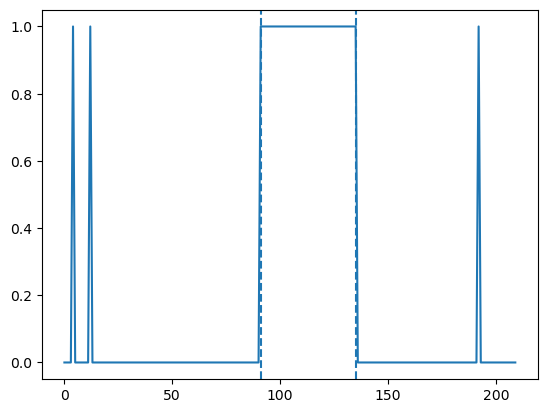

In [134]:
pixels = []
for frame in cropped_frames:
    pixels.append(int(frame.sum() > 0))

x = np.arange(0, frame_count)

plt.plot(x, pixels)

# find the longest time interval between zeros
pixels = np.pad(pixels, (1, 1), mode='constant')
diffs = np.diff(pixels)
starts = np.where(diffs == 1)[0]
ends = np.where(diffs == -1)[0]
lens = ends-starts
max_idx = np.argmax(lens)
start = starts[max_idx]
end = ends[max_idx] - 1

plt.axvline(start, linestyle='--')
plt.axvline(end, linestyle='--')

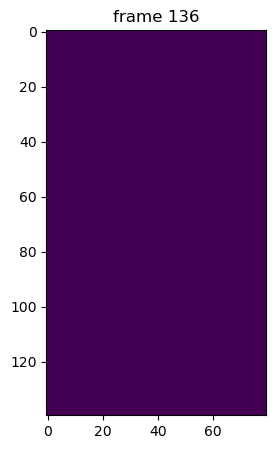

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))

im = ax.imshow(cropped_frames[start])

for i in range(start, end+2): # keep one extra frame after exiting the range
    im.set_data(cropped_frames[i])
    ax.set_title(f"frame {i}")
    # rerender
    display.display(plt.gcf())
    display.clear_output(wait=True)
    time.sleep(0.1)

In [ ]:
# the video can be cropped down to between the markers
# pure image data actually has both ball size (proxy of mass) and terminal velocity
#   (possible convolutional network)

# attempt 1: cut down the frames to just the area between markers

# possibly, instead of grayscale use some other transformation or one of the channels


### manual calculations

In [ ]:
frame_durations = {
    '6mm' : 5,
    '5mm' : 21
}

In [ ]:
frame_duration_6 = 42 - 27 
seconds_per_frame = 1 / 30
m_per_ml = 0.0185 / 20

time_duration_6 = frame_duration_6 * seconds_per_frame 
v_6 = 100*m_per_ml / time_duration_6

print(f"velocity in m/s: {v_6}")

0.0925
velocity in m/s: 0.185


In [89]:
def velocity(frame_duration):
    seconds_per_frame = 1 / 30
    m_per_ml = 0.0185 / 20
    return 100*m_per_ml / (frame_duration * seconds_per_frame)

In [77]:
def predicted_velocity(r):
    roB = 7700
    roG = 1261
    nu = 0.8
    V = 4 / 3 * np.pi * r**3
    return V * (roB * 9.81 - roG) / 6 / np.pi / nu / r